In [1]:
import pandas as pd 
import numpy as np

import seaborn as sns
import matplotlib.pyplot  as plt


from pathlib import Path

TAXI = Path("*Data/nyc_h9gi-nx95.csv")

In [2]:
taxi = pd.read_csv(TAXI)

taxi.shape

(150000, 29)

In [3]:
taxi.head()


,crash_date,crash_time,borough,zip_code,latitude,longitude,location,cross_street_name,number_of_persons_injured,number_of_pedestrians_injured,...,vehicle_type_code2,on_street_name,off_street_name,contributing_factor_vehicle_3,vehicle_type_code_3,contributing_factor_vehicle_4,contributing_factor_vehicle_5,vehicle_type_code_4,vehicle_type_code_5,number_of_persons_killed
0,2026-06-02T00:00:00.000,17:19,QUEENS,11421.0,40.698593,-73.852480,"{'latitude': '40.698593', 'longitude': '-73.85...",83-85 WOODHAVEN BLVD,1,0,...,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-06-02T00:00:00.000,8:20,BRONX,10463.0,40.882400,-73.908010,"{'latitude': '40.8824', 'longitude': '-73.9080...",NaN,0,0,...,4 dr sedan,IRWIN AVE,W 232 ST,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-06-02T00:00:00.000,22:30,QUEENS,11423.0,40.709526,-73.768260,"{'latitude': '40.709526', 'longitude': '-73.76...",NaN,1,0,...,Motorcycle,FARMERS BLVD,99 AVE,Unspecified,Motorcycle,NaN,NaN,NaN,NaN,NaN
3,2026-06-02T00:00:00.000,7:04,BROOKLYN,11201.0,40.693490,-73.979164,"{'latitude': '40.69349', 'longitude': '-73.979...",NaN,1,0,...,ESST,MYRTLE AVE,ASHLAND PL,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2026-06-02T00:00:00.000,17:01,BRONX,10458.0,40.854180,-73.886444,"{'latitude': '40.85418', 'longitude': '-73.886...",651 CRESCENT AVE,0,0,...,4 dr sedan,NaN,NaN,Unspecified,4 dr sedan,Unspecified,Unspecified,4 dr sedan,4 dr sedan,NaN


## Time analysis 
We want to understand the average weekly behavior, at first. Intuitively, which is most of the time the best way to perferom statistical analyis, we can immagine different "layer" of "seasonality"/"trend". We can think that there is a common pattern each weeks. As we know from our experience each monday of the week share something that is, on average, similar to each others. 

We will start from tis intuition. 

### Time Manipulation
Here we are taking from the dataset the two variables: "crash_date" and "crash_time". 

Starting from the date variable, we only need the first 10 characters. So that we will discard the fittitious hour in the end, and merge it with the "tru" hour from the time variable. 

In [4]:
time = taxi[["crash_time", "crash_date", "number_of_persons_injured", "borough"]].copy()

date = time["crash_date"].str[:10] + ' ' + time["crash_time"]

time["dt"] = pd.to_datetime(date, format = '%Y-%m-%d %H:%M')
time["hour"] = pd.to_datetime(time["crash_time"], format= "%H:%M").dt.hour
print(time[["dt", "hour"]].head(3))

                   dt  hour
0 2026-06-02 17:19:00    17
1 2026-06-02 08:20:00     8
2 2026-06-02 22:30:00    22


So now we have an actual "date" variable with a good handling of date and hour features. What we might want know are variables that helps us with classical timing handling. We can add variable that represent the day of the week, the week of the year and so on. 

Coming from a Stata background i want to have a variable that is a numerical variable behind the scenes and has a nice labeled visualization. For this reasson in python we need to make some work: 


In [5]:
#Day of the week variable
time["dow_num"] = time["dt"].dt.dayofweek
time["dow_name"] = time["dt"].dt.day_name()
time.head(4)


,crash_time,crash_date,number_of_persons_injured,borough,dt,hour,dow_num,dow_name
0,17:19,2026-06-02T00:00:00.000,1,QUEENS,2026-06-02 17:19:00,17,1,Tuesday
1,8:20,2026-06-02T00:00:00.000,0,BRONX,2026-06-02 08:20:00,8,1,Tuesday
2,22:30,2026-06-02T00:00:00.000,1,QUEENS,2026-06-02 22:30:00,22,1,Tuesday
3,7:04,2026-06-02T00:00:00.000,1,BROOKLYN,2026-06-02 07:04:00,7,1,Tuesday


Now, to put the nice lable: 

In [6]:
day = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

label = time["dt"].dt.dayofweek.map(dict(enumerate(day)))
print(label.head(3))
time["dow"]=pd.Categorical(label, categories= day, ordered = True)
time

0    Tue
1    Tue
2    Tue
Name: dt, dtype: object


,crash_time,crash_date,number_of_persons_injured,borough,dt,hour,dow_num,dow_name,dow
0,17:19,2026-06-02T00:00:00.000,1,QUEENS,2026-06-02 17:19:00,17,1,Tuesday,Tue
1,8:20,2026-06-02T00:00:00.000,0,BRONX,2026-06-02 08:20:00,8,1,Tuesday,Tue
2,22:30,2026-06-02T00:00:00.000,1,QUEENS,2026-06-02 22:30:00,22,1,Tuesday,Tue
3,7:04,2026-06-02T00:00:00.000,1,BROOKLYN,2026-06-02 07:04:00,7,1,Tuesday,Tue
4,17:01,2026-06-02T00:00:00.000,0,BRONX,2026-06-02 17:01:00,17,1,Tuesday,Tue
...,...,...,...,...,...,...,...,...,...
149995,20:30,2024-09-03T00:00:00.000,0,BROOKLYN,2024-09-03 20:30:00,20,1,Tuesday,Tue
149996,7:20,2024-09-03T00:00:00.000,0,MANHATTAN,2024-09-03 07:20:00,7,1,Tuesday,Tue
149997,22:45,2024-09-03T00:00:00.000,0,QUEENS,2024-09-03 22:45:00,22,1,Tuesday,Tue
149998,10:10,2024-09-03T00:00:00.000,1,BROOKLYN,2024-09-03 10:10:00,10,1,Tuesday,Tue


/var/folders/mc/16b1fcvs5pxgqz96bp4ymyvm0000gn/T/ipykernel_93320/2309044980.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  average = time.groupby(["dow", "hour"])["number_of_persons_injured"].mean()


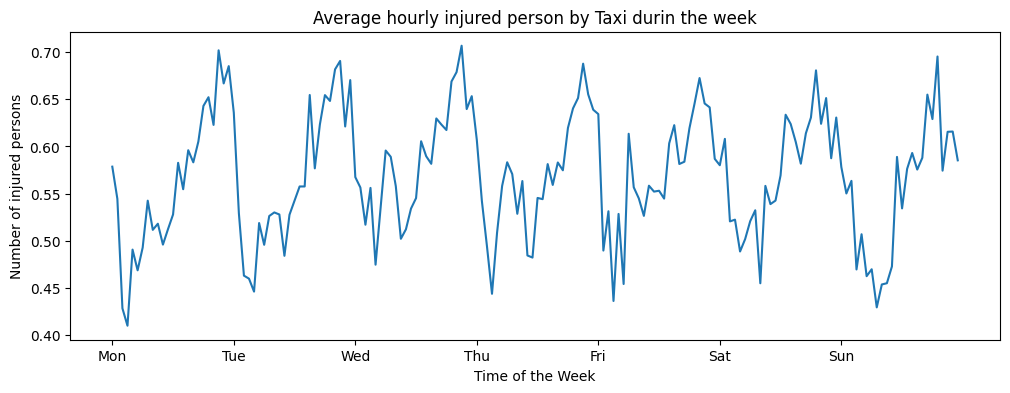

In [7]:

fig, ax = plt.subplots(figsize = (12, 4))
average = time.groupby(["dow", "hour"])["number_of_persons_injured"].mean()
average.plot(ax = ax)
_ = ax.set(
    title = "Average hourly injured person by Taxi durin the week", 
    xticks = [i * 24 for i in range(7)], 
    xticklabels = day,
    xlabel = "Time of the Week", 
    ylabel = "Number of injured persons"
)



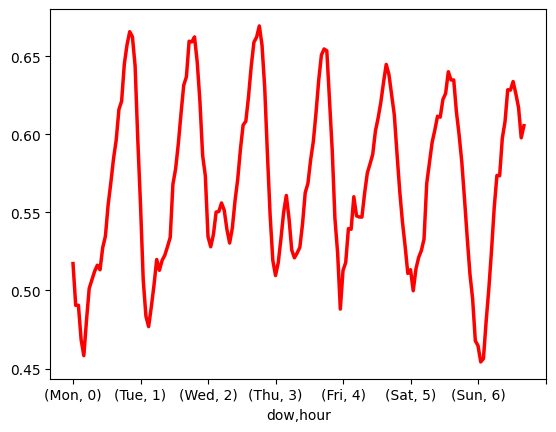

In [8]:
average.plot(ax = ax, alpha = 0.4, label = "media oraria")
average.rolling(5, center = True, min_periods = 1).mean().plot(color = "red", linewidth = 2.5,
                label = "smoother (average mobile 5h)")
ax.legend()

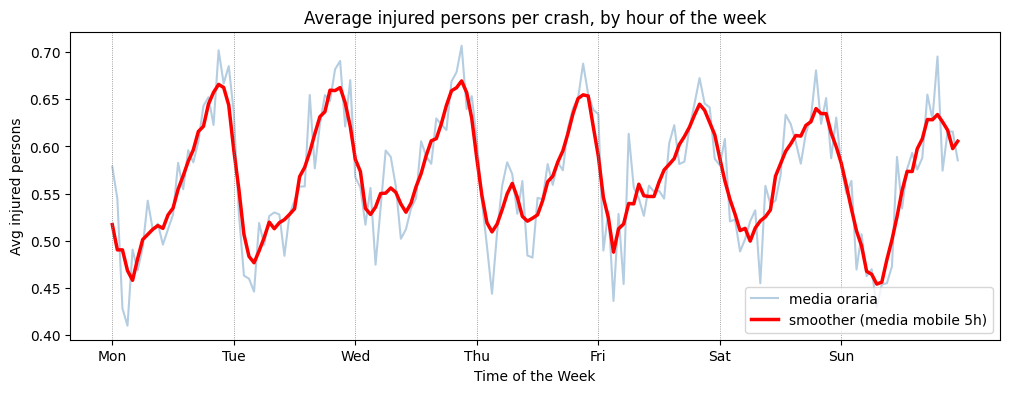

In [9]:
fig, ax = plt.subplots(figsize=(12, 4))

average.plot(ax=ax, color="steelblue", alpha=0.4, label="media oraria")

average.rolling(5, center=True, min_periods=1).mean().plot(
    ax=ax, color="red", linewidth=2.5, label="smoother (media mobile 5h)"
)

for i in range(7):
    ax.axvline(i * 24, color="grey", linestyle=":", linewidth=0.6)

_ = ax.set(
    title="Average injured persons per crash, by hour of the week",
    xticks=[i * 24 for i in range(7)],
    xticklabels=day,
    xlabel="Time of the Week",
    ylabel="Avg injured persons",
)
ax.legend()

We, want to model statistically what is happening. Let's try to see if the latitude and longitude can give us some interesting prospective into the distribution of accidents

<Axes: ylabel='Frequency'>

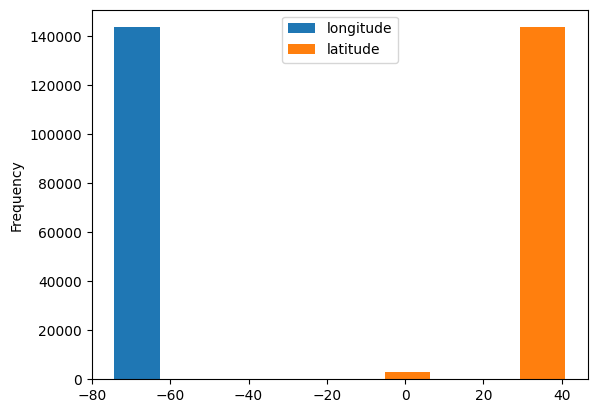

In [10]:
taxi[["longitude","latitude"]].plot(kind = "hist")

In [11]:
taxi.columns

Index(['crash_date', 'crash_time', 'borough', 'zip_code', 'latitude',
       'longitude', 'location', 'cross_street_name',
       'number_of_persons_injured', 'number_of_pedestrians_injured',
       'number_of_pedestrians_killed', 'number_of_cyclist_injured',
       'number_of_cyclist_killed', 'number_of_motorist_injured',
       'number_of_motorist_killed', 'contributing_factor_vehicle_1',
       'contributing_factor_vehicle_2', 'collision_id', 'vehicle_type_code1',
       'vehicle_type_code2', 'on_street_name', 'off_street_name',
       'contributing_factor_vehicle_3', 'vehicle_type_code_3',
       'contributing_factor_vehicle_4', 'contributing_factor_vehicle_5',
       'vehicle_type_code_4', 'vehicle_type_code_5',
       'number_of_persons_killed'],
      dtype='object')

/var/folders/mc/16b1fcvs5pxgqz96bp4ymyvm0000gn/T/ipykernel_93320/2008572287.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = time.groupby(["dow", "hour", "borough"])["number_of_persons_injured"].sum().reset_index()


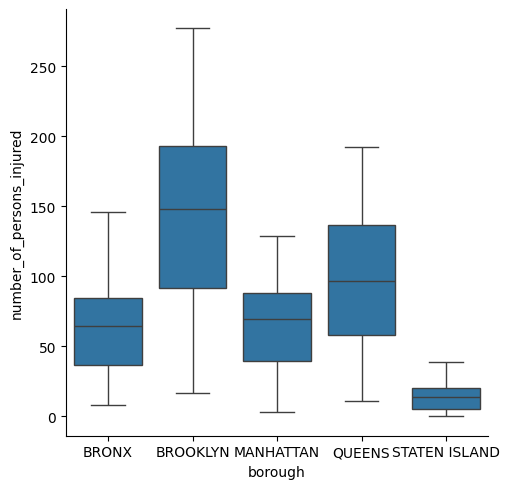

In [12]:
cols = [["number_of_motorist_injured", "number_of_motorist_killed", "number_of_cyclist_killed", 
         "number_of_cyclist_injured"]]

agg = time.groupby(["dow", "hour", "borough"])["number_of_persons_injured"].sum().reset_index()
agg

sns.catplot(data = agg, x = "borough", y = "number_of_persons_injured", kind = "box")

We want to predict, in this case, the number of people injured on an hourly basis.

In [13]:
df = time.groupby(["dow", "hour"])["number_of_persons_injured"].sum().reset_index()

df["number_of_persons_injured"].max()


/var/folders/mc/16b1fcvs5pxgqz96bp4ymyvm0000gn/T/ipykernel_93320/1664216328.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = time.groupby(["dow", "hour"])["number_of_persons_injured"].sum().reset_index()


np.int64(893)

In order to predict a relative injuring, let's rescale the target variavle so that the mean absolute error is more easily interpreted as a function of the maximum "injuring". 

In [20]:
time["borough"] = time["borough"].fillna("UNKOWN")

In [25]:
panel = (
    time.set_index("dt")
        .groupby("borough")["number_of_persons_injured"]
        .resample("h")
        .sum()
        .rename("injured")
        .reset_index()
)

panel["hour"] = panel["dt"].dt.hour 
panel["dow"] = panel["dt"].dt.dayofweek
panel["week"] = panel["dt"].dt.isocalendar().week.astype(int)
panel["year"] = panel["dt"].dt.year